In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
from google.colab import files

uploaded = files.upload()

Saving Superstore dataset_2.csv to Superstore dataset_2 (2).csv


In [60]:
df = pd.read_csv("Superstore dataset_2.csv", encoding='cp1252')

In [61]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [62]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 9994
Number of Columns: 21


In [63]:
df.shape

(9994, 21)

In [64]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [66]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [67]:
df.duplicated().sum()

np.int64(0)

In [68]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [69]:
for column in df.columns:
    print(column, ":", df[column].nunique())

Row ID : 9994
Order ID : 5009
Order Date : 1238
Ship Date : 1334
Ship Mode : 4
Customer ID : 793
Customer Name : 793
Segment : 3
Country : 1
City : 531
State : 49
Postal Code : 631
Region : 4
Product ID : 1862
Category : 3
Sub-Category : 17
Product Name : 1841
Sales : 5825
Quantity : 14
Discount : 12
Profit : 7287


# Data Cleaning & Preprocessing

In [70]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [71]:
df["Order Date"] = pd.to_datetime(df["Order Date"],format='%d-%m-%Y')
df["Ship Date"] = pd.to_datetime(df["Ship Date"],format='%d-%m-%Y')

In [72]:
print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [73]:
print("Start Date:", df["Order Date"].min())
print("End Date:", df["Order Date"].max())

Start Date: 2011-01-04 00:00:00
End Date: 2014-12-31 00:00:00


In [74]:
negative_sales = df[df["Sales"] < 0]

print("Negative Sales Records:", len(negative_sales))

Negative Sales Records: 0


In [75]:
print("Negative Profit Records:", (df["Profit"] < 0).sum())

Negative Profit Records: 1871


# Monthly Sales Dataset

In [76]:
monthly_sales = df.copy()

In [77]:
monthly_sales = monthly_sales.set_index("Order Date")

In [78]:
monthly_sales = monthly_sales["Sales"].resample("MS").sum()

In [79]:
monthly_sales.head(10)

,Sales
Order Date,
2011-01-01,13946.2290
2011-02-01,4810.5580
2011-03-01,55691.0090
2011-04-01,28295.3450
2011-05-01,23648.2870
2011-06-01,34595.1276
2011-07-01,33946.3930
2011-08-01,27909.4685
2011-09-01,81777.3508


In [80]:
print(monthly_sales.head())
print(monthly_sales.tail())

Order Date
2011-01-01    13946.229
2011-02-01     4810.558
2011-03-01    55691.009
2011-04-01    28295.345
2011-05-01    23648.287
Freq: MS, Name: Sales, dtype: float64
Order Date
2014-08-01     61516.0860
2014-09-01     90488.7220
2014-10-01     77793.7552
2014-11-01    112326.4710
2014-12-01     90474.6008
Freq: MS, Name: Sales, dtype: float64


# Visualize Historical Sales

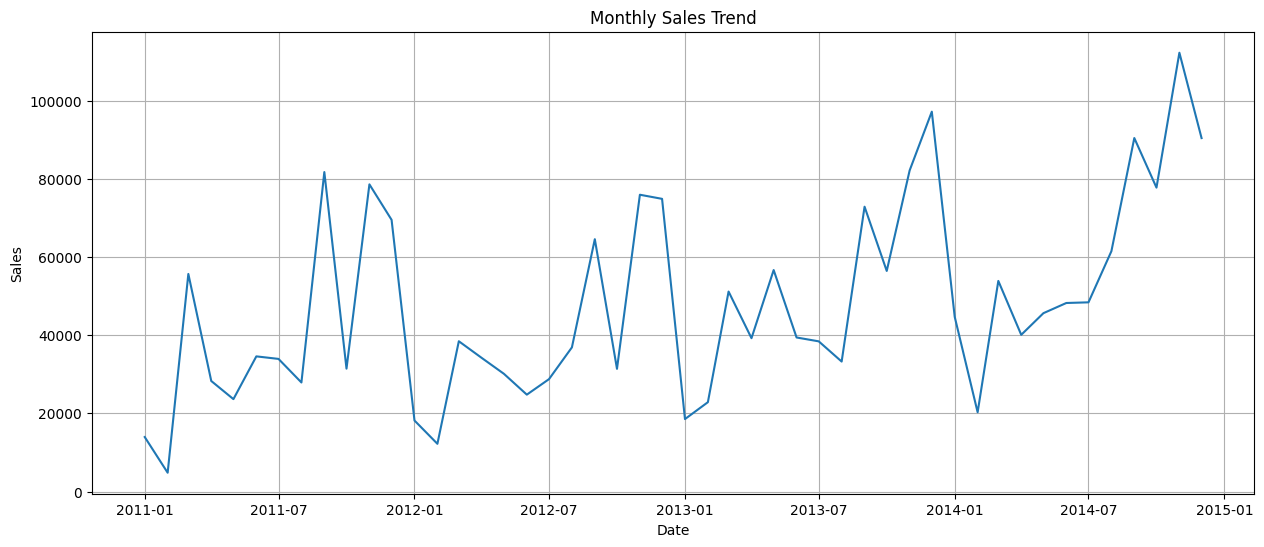

In [81]:
plt.figure(figsize=(15, 6))

plt.plot(monthly_sales.index, monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)
plt.show()

# Time-Based Features

In [82]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Quarter"] = df["Order Date"].dt.quarter
df["Month_Name"] = df["Order Date"].dt.month_name()

In [83]:
df[["Order Date", "Year", "Month", "Quarter", "Month_Name"]].head()

,Order Date,Year,Month,Quarter,Month_Name
0,2013-11-09,2013,11,4,November
1,2013-11-09,2013,11,4,November
2,2013-06-13,2013,6,2,June
3,2012-10-11,2012,10,4,October
4,2012-10-11,2012,10,4,October


# Lag features

In [84]:
forecast_df = monthly_sales.to_frame(name="Sales")

In [85]:
forecast_df["Lag_1"] = forecast_df["Sales"].shift(1)
forecast_df["Lag_3"] = forecast_df["Sales"].shift(3)
forecast_df["Lag_12"] = forecast_df["Sales"].shift(12)

In [86]:
forecast_df["Rolling_Mean_3"] = forecast_df["Sales"].rolling(3).mean()
forecast_df["Rolling_Mean_12"] = forecast_df["Sales"].rolling(12).mean()

In [87]:
forecast_df.head(15)

,Sales,Lag_1,Lag_3,Lag_12,Rolling_Mean_3,Rolling_Mean_12
Order Date,,,,,,
2011-01-01,13946.2290,NaN,NaN,NaN,NaN,NaN
2011-02-01,4810.5580,13946.2290,NaN,NaN,NaN,NaN
2011-03-01,55691.0090,4810.5580,NaN,NaN,24815.932000,NaN
2011-04-01,28295.3450,55691.0090,13946.2290,NaN,29598.970667,NaN
2011-05-01,23648.2870,28295.3450,4810.5580,NaN,35878.213667,NaN
2011-06-01,34595.1276,23648.2870,55691.0090,NaN,28846.253200,NaN
2011-07-01,33946.3930,34595.1276,28295.3450,NaN,30729.935867,NaN
2011-08-01,27909.4685,33946.3930,23648.2870,NaN,32150.329700,NaN
2011-09-01,81777.3508,27909.4685,34595.1276,NaN,47877.737433,NaN


# Remove Initial Missing Values

In [88]:
forecast_df = forecast_df.dropna()

In [89]:
forecast_df.isnull().sum()

,0
Sales,0
Lag_1,0
Lag_3,0
Lag_12,0
Rolling_Mean_3,0
Rolling_Mean_12,0


# Prepare Training & Testing data

In [90]:
train_size = int(len(forecast_df) * 0.80)

train = forecast_df.iloc[:train_size]
test = forecast_df.iloc[train_size:]

In [91]:
print("Training records:", len(train))
print("Testing records:", len(test))

Training records: 28
Testing records: 8


In [92]:
print("Training period:", train.index.min(), "to", train.index.max())
print("Testing period:", test.index.min(), "to", test.index.max())

Training period: 2012-01-01 00:00:00 to 2014-04-01 00:00:00
Testing period: 2014-05-01 00:00:00 to 2014-12-01 00:00:00


# Linear Regression Model

In [93]:
# Create time-based features
forecast_df["Year"] = forecast_df.index.year
forecast_df["Month"] = forecast_df.index.month

In [94]:
train_size = int(len(forecast_df) * 0.80)

train = forecast_df.iloc[:train_size].copy()
test = forecast_df.iloc[train_size:].copy()

In [95]:
features = [
    "Year",
    "Month",
    "Lag_1",
    "Lag_3",
    "Lag_12",
    "Rolling_Mean_3",
    "Rolling_Mean_12"
]

In [96]:
X_train = train[features]
y_train = train["Sales"]

X_test = test[features]
y_test = test["Sales"]

In [97]:
print("Features:")
print(features)

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining columns:")
print(X_train.columns.tolist())

Features:
['Year', 'Month', 'Lag_1', 'Lag_3', 'Lag_12', 'Rolling_Mean_3', 'Rolling_Mean_12']

X_train shape: (28, 7)
X_test shape: (8, 7)

Training columns:
['Year', 'Month', 'Lag_1', 'Lag_3', 'Lag_12', 'Rolling_Mean_3', 'Rolling_Mean_12']


In [98]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


# Random Forest Regression

In [99]:
from sklearn.ensemble import RandomForestRegressor

In [100]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=None
)

In [101]:
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [102]:
rf_predictions = rf_model.predict(X_test)

print("Random Forest predictions generated successfully!")

Random Forest predictions generated successfully!


# Evaluate Both Models

In [103]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [104]:
def evaluate_model(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    # Avoid division by zero
    non_zero = actual != 0
    mape = np.mean(
        np.abs((actual[non_zero] - predicted[non_zero]) / actual[non_zero])
    ) * 100

    return mae, rmse, mape

In [105]:
lr_mae, lr_rmse, lr_mape = evaluate_model(
    y_test,
    lr_predictions
)

print("Linear Regression")
print("-------------------------")
print("MAE :", round(lr_mae, 2))
print("RMSE:", round(lr_rmse, 2))
print("MAPE:", round(lr_mape, 2), "%")

Linear Regression
-------------------------
MAE : 8221.05
RMSE: 10391.24
MAPE: 12.44 %


In [106]:
rf_mae, rf_rmse, rf_mape = evaluate_model(
    y_test,
    rf_predictions
)

print("Random Forest")
print("-------------------------")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("MAPE:", round(rf_mape, 2), "%")

Random Forest
-------------------------
MAE : 11254.82
RMSE: 14676.47
MAPE: 14.34 %


# Model Comparison Table

In [107]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse
    ],
    "MAPE (%)": [
        lr_mape,
        rf_mape
    ]
})

results

,Model,MAE,RMSE,MAPE (%)
0,Linear Regression,8221.053999,10391.236011,12.436173
1,Random Forest,11254.816281,14676.468980,14.343755


# Actual vs Predicted Sales

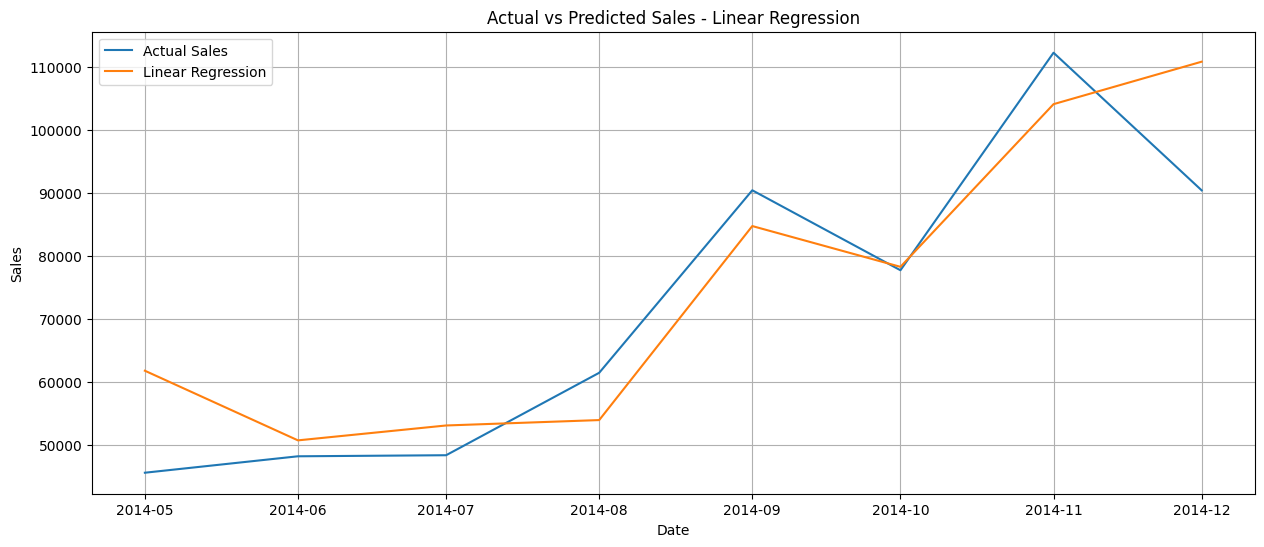

In [108]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_test.index,
    y_test.values,
    label="Actual Sales"
)

plt.plot(
    y_test.index,
    lr_predictions,
    label="Linear Regression"
)

plt.title("Actual vs Predicted Sales - Linear Regression")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)
plt.show()

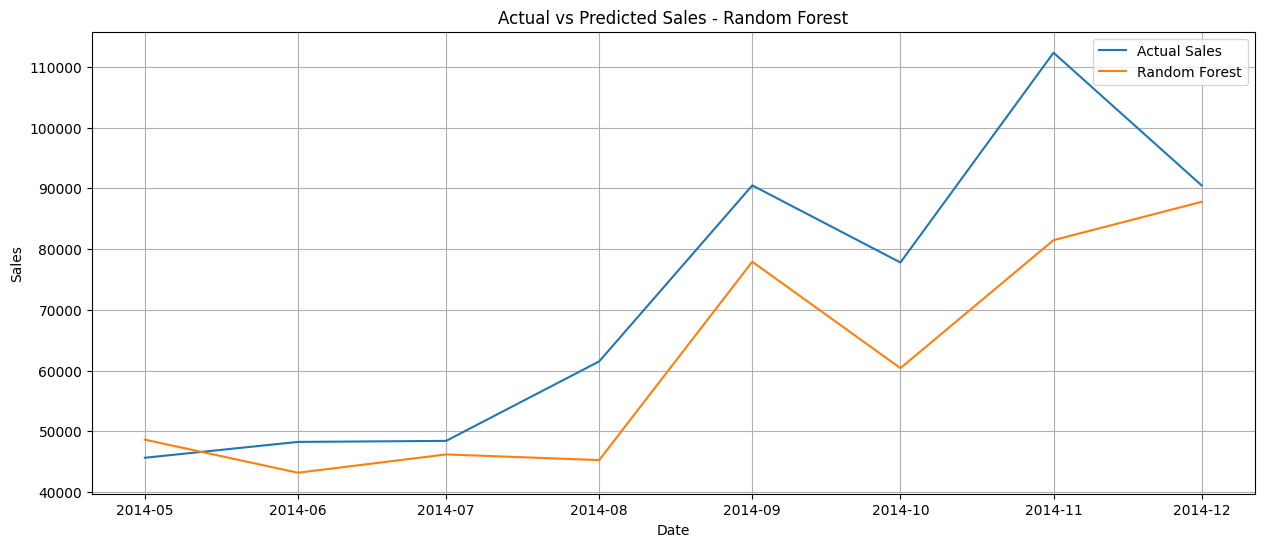

In [109]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_test.index,
    y_test.values,
    label="Actual Sales"
)

plt.plot(
    y_test.index,
    rf_predictions,
    label="Random Forest"
)

plt.title("Actual vs Predicted Sales - Random Forest")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)
plt.show()

# Feature Importance

In [110]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,Lag_12,0.583173
1,Month,0.228244
6,Rolling_Mean_12,0.065113
3,Lag_3,0.039598
5,Rolling_Mean_3,0.039455
2,Lag_1,0.026250
0,Year,0.018166


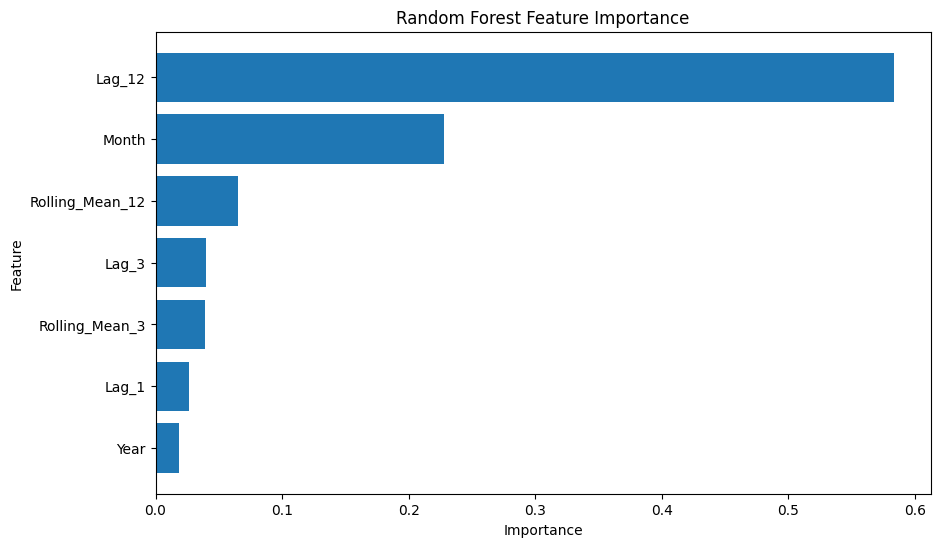

In [111]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

# SARIMA Model

In [112]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [113]:
sarima_model = SARIMAX(
    train["Sales"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

In [114]:
sarima_result = sarima_model.fit(disp=False)

print("SARIMA model trained successfully!")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA model trained successfully!


In [117]:
sarima_predictions = sarima_result.forecast(
    steps=len(test)
)

# Evaluate SARIMA

In [118]:
sarima_mae, sarima_rmse, sarima_mape = evaluate_model(
    y_test,
    sarima_predictions
)

print("SARIMA")
print("-------------------------")
print("MAE :", round(sarima_mae, 2))
print("RMSE:", round(sarima_rmse, 2))
print("MAPE:", round(sarima_mape, 2), "%")

SARIMA
-------------------------
MAE : 16289.34
RMSE: 18706.81
MAPE: 23.5 %


# Final Model Comparison

In [119]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "SARIMA"
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        sarima_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        sarima_rmse
    ],
    "MAPE (%)": [
        lr_mape,
        rf_mape,
        sarima_mape
    ]
})

results.sort_values("MAPE (%)")

,Model,MAE,RMSE,MAPE (%)
0,Linear Regression,8221.053999,10391.236011,12.436173
1,Random Forest,11254.816281,14676.468980,14.343755
2,SARIMA,16289.344384,18706.808025,23.502864


# Plot SARIMA Prediction

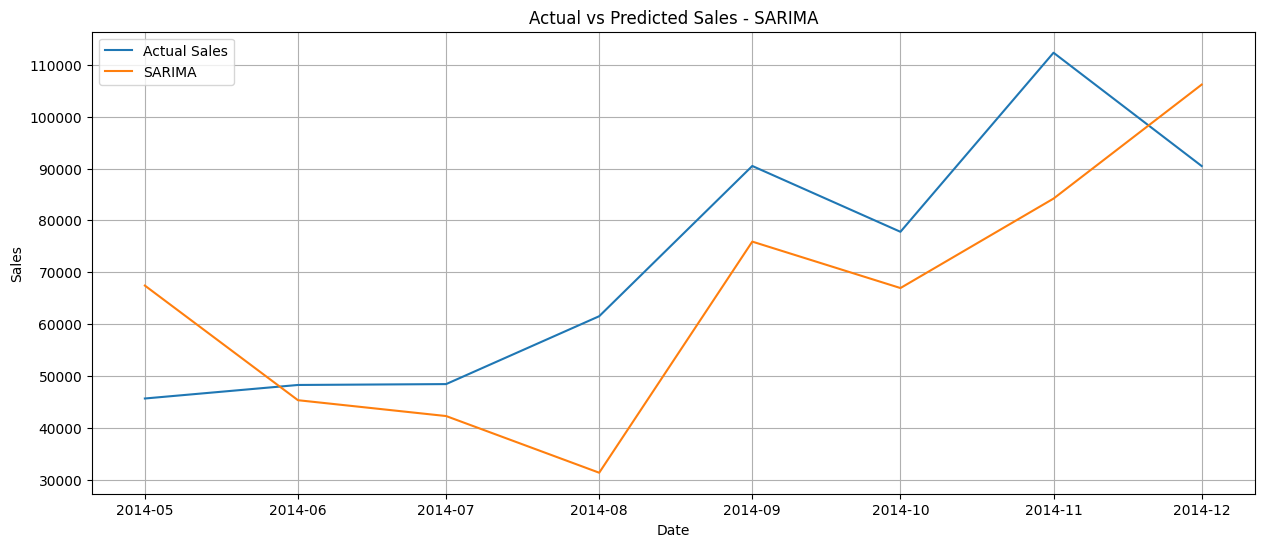

In [120]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_test.index,
    y_test.values,
    label="Actual Sales"
)

plt.plot(
    y_test.index,
    sarima_predictions.values,
    label="SARIMA"
)

plt.title("Actual vs Predicted Sales - SARIMA")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)
plt.show()

# Select the Best Model

In [121]:
best_model = results.loc[
    results["MAPE (%)"].idxmin(),
    "Model"
]

print("Best Model:", best_model)

Best Model: Linear Regression


In [122]:
print(results.sort_values("MAPE (%)"))

               Model           MAE          RMSE   MAPE (%)
0  Linear Regression   8221.053999  10391.236011  12.436173
1      Random Forest  11254.816281  14676.468980  14.343755
2             SARIMA  16289.344384  18706.808025  23.502864


# Prepare Data for Future Forecasting

In [123]:
print("Last historical month:", forecast_df.index.max())
print("Last actual sales:", round(forecast_df["Sales"].iloc[-1], 2))

Last historical month: 2014-12-01 00:00:00
Last actual sales: 90474.6


# Generate Next 12 Months

In [124]:
future_dates = pd.date_range(
    start=forecast_df.index.max() + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

future_dates

DatetimeIndex(['2015-01-01', '2015-02-01', '2015-03-01', '2015-04-01',
               '2015-05-01', '2015-06-01', '2015-07-01', '2015-08-01',
               '2015-09-01', '2015-10-01', '2015-11-01', '2015-12-01'],
              dtype='datetime64[ns]', freq='MS')

# Generate Future Predictions

In [125]:
# Copy historical sales
sales_history = forecast_df["Sales"].copy()

future_predictions = []

for date in future_dates:

    # Create features
    year = date.year
    month = date.month

    lag_1 = sales_history.iloc[-1]

    lag_3 = sales_history.iloc[-3]

    lag_12 = sales_history.iloc[-12]

    rolling_mean_3 = sales_history.iloc[-3:].mean()

    rolling_mean_12 = sales_history.iloc[-12:].mean()

    # Create feature row
    future_features = pd.DataFrame({
        "Year": [year],
        "Month": [month],
        "Lag_1": [lag_1],
        "Lag_3": [lag_3],
        "Lag_12": [lag_12],
        "Rolling_Mean_3": [rolling_mean_3],
        "Rolling_Mean_12": [rolling_mean_12]
    })

    # Predict
    prediction = lr_model.predict(future_features)[0]

    # Store prediction
    future_predictions.append(prediction)

    # Add prediction to history
    sales_history.loc[date] = prediction

# Forecast DataFrame

In [126]:
future_forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted_Sales": future_predictions
})

future_forecast_df

,Date,Forecasted_Sales
0,2015-01-01,68999.368312
1,2015-02-01,55679.523247
2,2015-03-01,71150.658671
3,2015-04-01,60701.727518
4,2015-05-01,65790.142749
5,2015-06-01,69740.510093
6,2015-07-01,71245.635210
7,2015-08-01,82220.820995
8,2015-09-01,102867.068874
9,2015-10-01,99868.896482


In [127]:
future_forecast_df["Forecasted_Sales"] = (
    future_forecast_df["Forecasted_Sales"].round(2)
)

future_forecast_df

,Date,Forecasted_Sales
0,2015-01-01,68999.37
1,2015-02-01,55679.52
2,2015-03-01,71150.66
3,2015-04-01,60701.73
4,2015-05-01,65790.14
5,2015-06-01,69740.51
6,2015-07-01,71245.64
7,2015-08-01,82220.82
8,2015-09-01,102867.07
9,2015-10-01,99868.90


In [128]:
total_forecast_sales = future_forecast_df["Forecasted_Sales"].sum()

print(
    "Total Forecasted Sales for Next 12 Months:",
    round(total_forecast_sales, 2)
)

Total Forecasted Sales for Next 12 Months: 994027.23


In [129]:
average_forecast_sales = future_forecast_df[
    "Forecasted_Sales"
].mean()

print(
    "Average Monthly Forecasted Sales:",
    round(average_forecast_sales, 2)
)

Average Monthly Forecasted Sales: 82835.6


In [130]:
highest_month = future_forecast_df.loc[
    future_forecast_df["Forecasted_Sales"].idxmax()
]

print(
    "Highest Forecast:",
    highest_month["Date"].strftime("%B %Y")
)

print(
    "Forecasted Sales:",
    round(highest_month["Forecasted_Sales"], 2)
)

Highest Forecast: November 2015
Forecasted Sales: 126809.97


In [131]:
lowest_month = future_forecast_df.loc[
    future_forecast_df["Forecasted_Sales"].idxmin()
]

print(
    "Lowest Forecast:",
    lowest_month["Date"].strftime("%B %Y")
)

print(
    "Forecasted Sales:",
    round(lowest_month["Forecasted_Sales"], 2)
)

Lowest Forecast: February 2015
Forecasted Sales: 55679.52


# Visualize Historical + Future Forecast

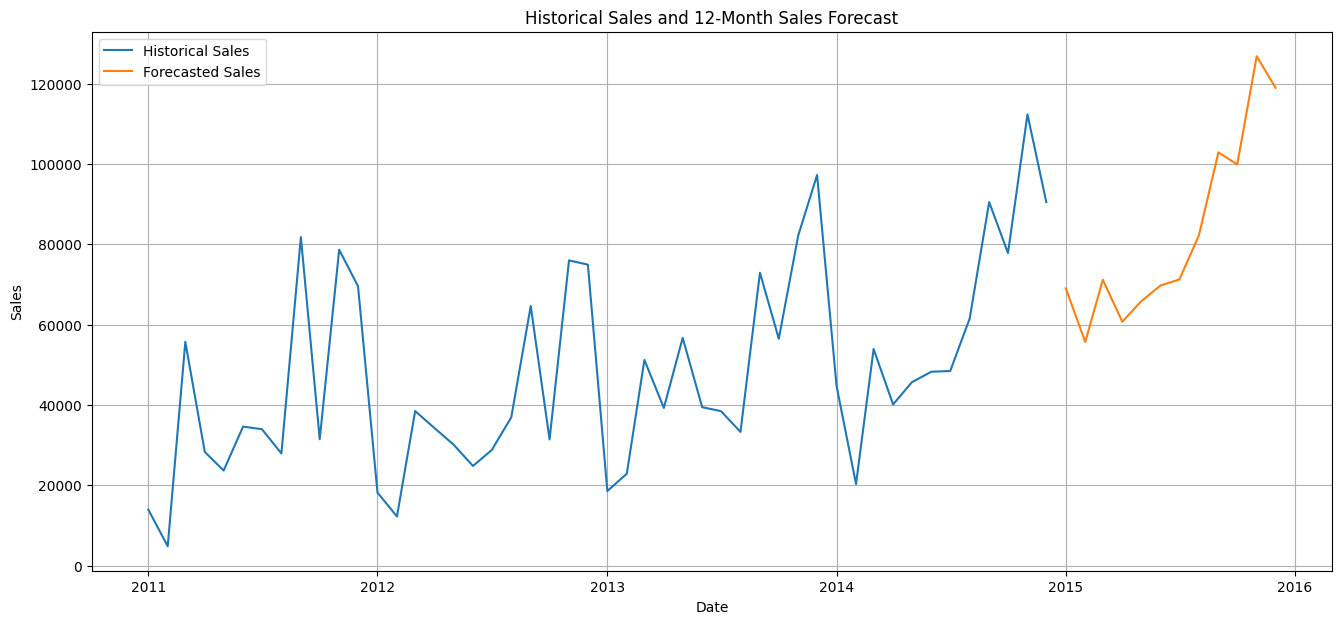

In [132]:
plt.figure(figsize=(16, 7))

# Historical sales
plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    label="Historical Sales"
)

# Future forecast
plt.plot(
    future_forecast_df["Date"],
    future_forecast_df["Forecasted_Sales"],
    label="Forecasted Sales"
)

plt.title("Historical Sales and 12-Month Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

# Plot only Future Forecast

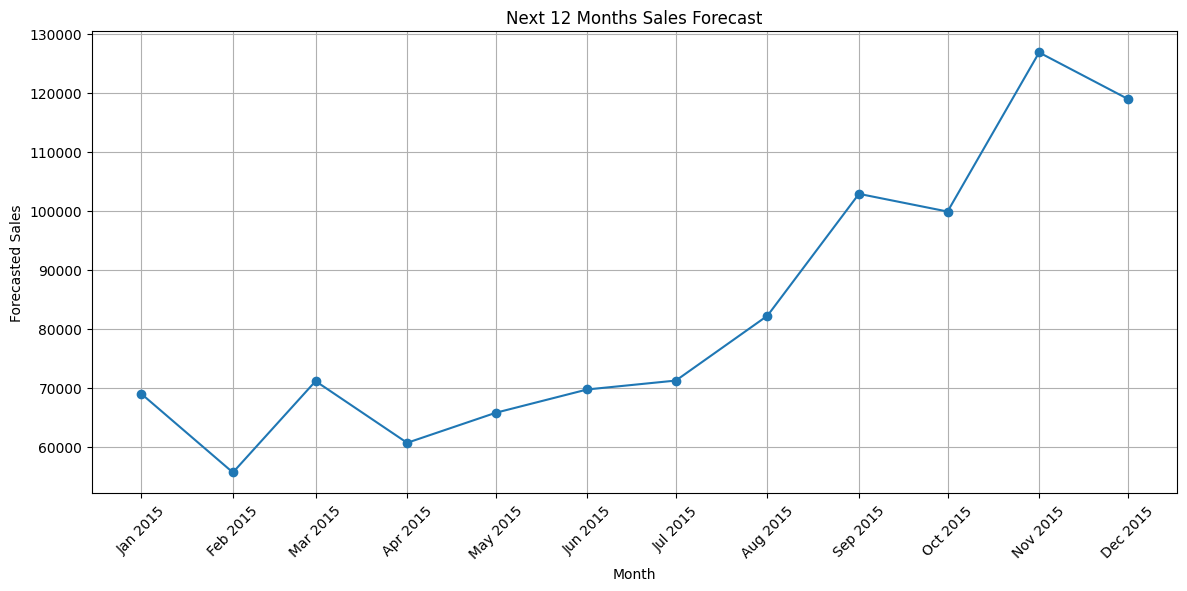

In [133]:
plt.figure(figsize=(14, 6))

plt.plot(
    future_forecast_df["Date"],
    future_forecast_df["Forecasted_Sales"],
    marker="o"
)

plt.title("Next 12 Months Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Forecasted Sales")

plt.xticks(
    future_forecast_df["Date"],
    future_forecast_df["Date"].dt.strftime("%b %Y"),
    rotation=45
)

plt.grid(True)

plt.show()

# Calculate Forecast Trend

In [134]:
first_forecast = future_forecast_df[
    "Forecasted_Sales"
].iloc[0]

last_forecast = future_forecast_df[
    "Forecasted_Sales"
].iloc[-1]

forecast_growth = (
    (last_forecast - first_forecast)
    / first_forecast
) * 100

print(
    "Forecast Change from First to Last Month:",
    round(forecast_growth, 2),
    "%"
)

Forecast Change from First to Last Month: 72.4 %


# Business Insights

In [136]:
print("KEY BUSINESS INSIGHTS")
print("============================")

print(
    f"1. The selected model for forecasting is Linear Regression."
)

print(
    f"2. Total forecasted sales for the next 12 months are "
    f"{total_forecast_sales:,.2f}."
)

print(
    f"3. Average monthly forecasted sales are "
    f"{average_forecast_sales:,.2f}."
)

print(
    f"4. The highest forecasted sales are expected in "
    f"{highest_month['Date'].strftime('%B %Y')} "
    f"with {highest_month['Forecasted_Sales']:,.2f}."
)

print(
    f"5. The lowest forecasted sales are expected in "
    f"{lowest_month['Date'].strftime('%B %Y')} "
    f"with {lowest_month['Forecasted_Sales']:,.2f}."
)

print(
    f"6. Sales are expected to change by "
    f"{forecast_growth:.2f}% from the first to the last forecast month."
)

KEY BUSINESS INSIGHTS
1. The selected model for forecasting is Linear Regression.
2. Total forecasted sales for the next 12 months are 994,027.23.
3. Average monthly forecasted sales are 82,835.60.
4. The highest forecasted sales are expected in November 2015 with 126,809.97.
5. The lowest forecasted sales are expected in February 2015 with 55,679.52.
6. Sales are expected to change by 72.40% from the first to the last forecast month.


# Save Forecast Results

In [137]:
future_forecast_df.to_csv(
    "Superstore_12_Month_Sales_Forecast.csv",
    index=False
)

print("Forecast file saved successfully!")

Forecast file saved successfully!


In [138]:
from google.colab import files

files.download(
    "Superstore_12_Month_Sales_Forecast.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Final Model Performance Table

In [139]:
final_results = results.copy()

final_results["MAE"] = final_results["MAE"].round(2)
final_results["RMSE"] = final_results["RMSE"].round(2)
final_results["MAPE (%)"] = final_results["MAPE (%)"].round(2)

final_results

,Model,MAE,RMSE,MAPE (%)
0,Linear Regression,8221.05,10391.24,12.44
1,Random Forest,11254.82,14676.47,14.34
2,SARIMA,16289.34,18706.81,23.50


# Save the Final Model

In [140]:
import joblib

joblib.dump(
    lr_model,
    "superstore_linear_regression_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!
